---
title: STEM Simulation and Post-Processing
authors: [Toma Susi]
date: 2024/12/30
---

In [2]:
import ase
import abtem
import matplotlib.pyplot as plt

atoms = ase.io.read("data/sto_lto.cif")
potential = abtem.Potential(atoms, sampling=0.05, slice_thickness=2)

probe = abtem.Probe(energy=150e3, defocus=50, semiangle_cutoff=20, Cs=0.0)

probe.grid.match(potential)

scan = abtem.GridScan(
    start=(0, 0),
    end=(1 / 3, 1),
    sampling=probe.ctf.nyquist_sampling, # Equal to 0.36963 A
    fractional=True,
    potential=potential,
)

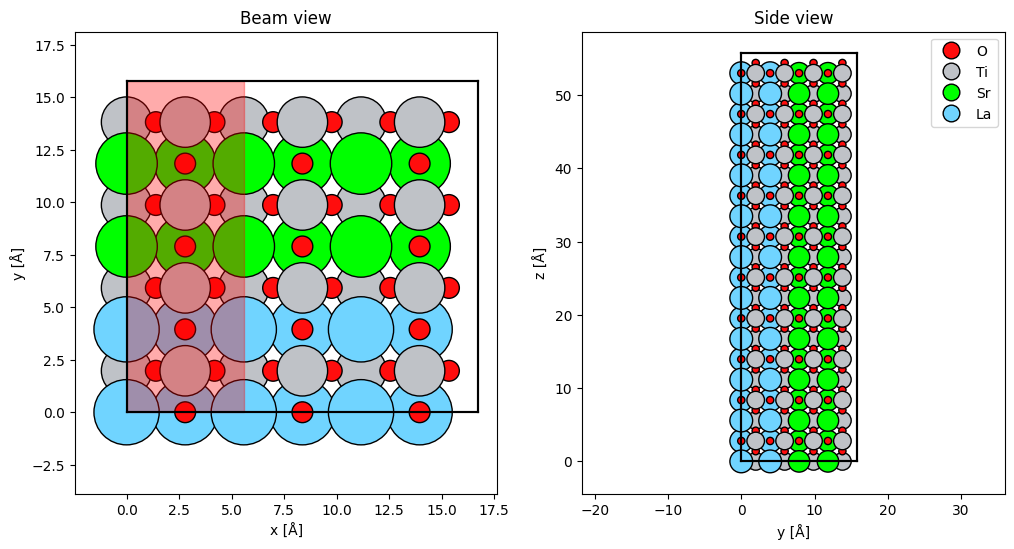

In [3]:
#| label: app:stem_sto-lto_scan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
abtem.show_atoms(atoms, ax=ax1, plane="xy", title="Beam view")
abtem.show_atoms(atoms, ax=ax2, plane="yz", title="Side view", legend=True);

scan.add_to_plot(ax1);

In [4]:
bright = abtem.AnnularDetector(inner=0, outer=20)
maadf = abtem.AnnularDetector(inner=40, outer=100)
haadf = abtem.AnnularDetector(inner=100, outer=180)

detectors = [bright, maadf, haadf]

In [5]:
scanned_measurements = probe.scan(
    scan=scan,
    detectors=detectors,
    potential=potential,
)

compute = False

if compute:
    scanned_measurements.compute()
    
    stacked_measurements = abtem.stack(scanned_measurements, ("BF", "MAADF", "HAADF"))
    
    stacked_measurements.to_zarr("data/STO_LTO_STEM.zarr");

else:
    stacked_measurements = abtem.from_zarr("data/STO_LTO_STEM.zarr").compute()

#stacked_measurements.show(explode=True);
#plt.savefig("../static/stem_images.png", dpi=600)

[########################################] | 100% Completed | 101.91 ms


In [6]:
interpolated_measurements = stacked_measurements.interpolate(0.05)
#interpolated_measurements.show(explode=True);

In [7]:
blurred_measurements = interpolated_measurements.gaussian_filter(0.35)
#blurred_measurements.show(explode=True);

In [8]:
noisy_measurements = blurred_measurements.poisson_noise(dose_per_area=1e5, seed=100)
#noisy_measurements.show(explode=True, figsize=(12, 4));

In [9]:
processed_measurements = abtem.stack([interpolated_measurements, blurred_measurements, noisy_measurements],
                               ("Interpolated", "Blurred", "Noised"))

In [10]:
# Images need to have the same number of pixels so we can stack them for easy visualization:
from scipy.ndimage import zoom

scalex = interpolated_measurements[0].shape[0]/stacked_measurements[0].array.shape[0]
scaley = interpolated_measurements[1].shape[1]/stacked_measurements[0].array.shape[1]

zoomed0 = zoom(stacked_measurements[0].array, (scalex, scaley), order=0)
zoomed1 = zoom(stacked_measurements[1].array, (scalex, scaley), order=0)
zoomed2 = zoom(stacked_measurements[2].array, (scalex, scaley), order=0)

from abtem import Images

image0 = Images(zoomed0, sampling = interpolated_measurements[0].sampling)
image1 = Images(zoomed1, sampling = interpolated_measurements[1].sampling)
image2 = Images(zoomed2, sampling = interpolated_measurements[2].sampling)

zoomed_measurements = abtem.stack([image0, image1, image2], ("BF", "MAADF", "HAADF"))

In [11]:
all_measurements = abtem.stack([zoomed_measurements, interpolated_measurements, blurred_measurements, noisy_measurements],
                               ("Nyquist-sampled", "Interpolated", "Blurred", "Noised"))

all_measurements.to_zarr("data/processed_STEM.zarr");

[########################################] | 100% Completed | 107.32 ms


In [12]:
%matplotlib ipympl

abtem.config.set({"visualize.cmap": "viridis"})
abtem.config.set({"visualize.continuous_update": True})
abtem.config.set({"visualize.autoscale": True})

all_measurements = abtem.from_zarr("data/processed_STEM.zarr")

In [13]:
#| label: app:stem_processing
viz = all_measurements.show(interact=True, explode=(1,), figsize=(5,5))

[########################################] | 100% Completed | 101.58 ms


ImageGUI(children=(VBox(children=(SelectionSlider(options=('Nyquist-sampled', 'Interpolated', 'Blurred', 'Nois…